In [1]:
class CFG:
    SEED = 42

    # ---------- Stage 1: Detector (YOLO11) ----------
    DETECTOR      = 'yolo11m.pt'   # 'yolo11m.pt' fits with batch=8 on 16GB Tesla T4
    DET_IMGSZ     = 1280
    DET_BATCH     = 8
    DET_EPOCHS    = 40
    DET_PATIENCE  = 8
    DET_LR        = 0.00087

    # ---------- Stage 2: Crop Segmenter (UNet++) ----------
    ENCODER       = 'efficientnet-b4'
    CROP_SIZE     = 512
    PAD_RATIO     = 0.20
    BOX_JITTER    = 0.12           # Simulates detector localization errors during segmenter training
    SEG_EPOCHS    = 14
    SEG_BATCH     = 8
    SEG_PATIENCE  = 7
    SEG_LR        = 2e-4
    TVERSKY_ALPHA = 0.30
    TVERSKY_BETA  = 0.70
    TVERSKY_GAMMA = 1.33           # Focal exponent for hard/thin filament barbs

    # ---------- Preprocessing ----------
    USE_CLAHE     = True           # Contrast Limited Adaptive Histogram Equalization for H-alpha contrast
    CLAHE_CLIP    = 2.0
    CLAHE_GRID    = (8, 8)

    # ---------- Inference & Panoptic Assembly ----------
    INFER_IMGSZ   = 1280           # Fixed: matches detector training size (1280)
    USE_TTA       = True           # Test-Time Augmentation (Horizontal + Vertical Flip for segmenter)
    CONF_MIN      = 0.05           # Low threshold for candidate box caching
    MAX_DET       = 70
    MIN_AREA      = 150            # Filters out spurious pixel noise (<150 px) to maximize DQ
    CLOSE_KERNEL  = 3              # Small morphological closing to bridge thin barb gaps

    # ---------- Validation Sweep ----------
    CONF_GRID     = [0.20, 0.25, 0.30, 0.35, 0.40, 0.45]
    MASK_GRID     = [0.40, 0.45, 0.50, 0.55, 0.60, 0.65]
    SWEEP_PHOTOS  = 40             # Subset for sweep (full val is evaluated in Cell 12)

    VAL_FRACTION  = 0.15

RUN_NAME = 'V2_enhanced'
print('Config loaded:', RUN_NAME)


Config loaded: V1_baseline


In [2]:
!pip install -q segmentation-models-pytorch ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.8/45.8 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 24.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.0/66.0 kB 4.8 MB/s eta 0:00:00


In [3]:
import os, json, shutil, time, random, gc
from pathlib import Path

import numpy as np
import pandas as pd
import cv2
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import CosineAnnealingLR
from sklearn.model_selection import train_test_split
from pycocotools.coco import COCO
from pycocotools import mask as mask_utils
import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2
import matplotlib.pyplot as plt

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(CFG.SEED); np.random.seed(CFG.SEED); random.seed(CFG.SEED)
torch.backends.cudnn.benchmark = True

ROOT = Path('/kaggle/input/competitions/filament-segmentation-2026/MAGFiLO_1.0_Kaggle_2026')
if not ROOT.exists():
    ROOT = Path('/kaggle/input/filament-segmentation-2026/MAGFiLO_1.0_Kaggle_2026')
TRAIN_JSON    = ROOT / 'train' / 'MAGFiLO_1.0_Annotations_kaggle2026_train.json'
TRAIN_IMG_DIR = ROOT / 'train' / 'train_images'
TEST_IMG_DIR  = ROOT / 'test'  / 'test_images'
assert TRAIN_JSON.exists(), f'Cannot find data in {ROOT}'

H = W = 2048
print('GPU:', torch.cuda.get_device_name(0) if DEVICE.type == 'cuda' else 'CPU')
print('train:', len(list(TRAIN_IMG_DIR.glob('*.jpeg'))), '| test:', len(list(TEST_IMG_DIR.glob('*.jpeg'))))

GPU: Tesla T4
train: 707 | test: 180


In [4]:
coco = COCO(str(TRAIN_JSON))

photo_to_ids = {}
for iid in coco.imgs:
    photo_to_ids.setdefault(coco.loadImgs([iid])[0]['file_name'], []).append(iid)

unique_photos = sorted(photo_to_ids)
train_photos, val_photos = train_test_split(unique_photos, test_size=CFG.VAL_FRACTION, random_state=CFG.SEED)

train_ids = [i for p in train_photos for i in photo_to_ids[p]]
val_ids   = [i for p in val_photos   for i in photo_to_ids[p]]
test_paths = sorted(TEST_IMG_DIR.glob('*.jpeg'))

print(f'Unique photos: {len(unique_photos)}  (train {len(train_photos)} / val {len(val_photos)})')
print(f'Annotator records: train {len(train_ids)} / val {len(val_ids)}')
print(f'Annotated filaments: {len(coco.anns)}')
print(f'Test images: {len(test_paths)}')


loading annotations into memory...
Done (t=0.88s)
creating index...
index created!
Unique photos: 707  (train 600 / val 107)
Annotator records: train 976 / val 178
Annotated filaments: 8199
Test images: 180


In [5]:
class FocalTverskyLoss(nn.Module):
    # Focal Tversky Loss: penalizes false negatives (barbs) and focuses on hard boundary pixels
    def __init__(self, alpha=CFG.TVERSKY_ALPHA, beta=CFG.TVERSKY_BETA, gamma=CFG.TVERSKY_GAMMA, smooth=1e-6):
        super().__init__()
        self.alpha, self.beta, self.gamma, self.smooth = alpha, beta, gamma, smooth

    def forward(self, logits, targets):
        p = torch.sigmoid(logits).view(-1); t = targets.view(-1)
        tp = (p * t).sum(); fp = (p * (1 - t)).sum(); fn = ((1 - p) * t).sum()
        tversky = (tp + self.smooth) / (tp + self.alpha * fp + self.beta * fn + self.smooth)
        return torch.pow(torch.clamp(1.0 - tversky, min=1e-7), 1.0 / self.gamma)


class BCETverskyLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()
        self.ftv = FocalTverskyLoss()

    def forward(self, logits, targets):
        return 0.4 * self.bce(logits, targets) + 0.6 * self.ftv(logits, targets)


def dice_score(logits, targets, thr=0.5, smooth=1e-6):
    p = (torch.sigmoid(logits) > thr).float().view(-1); t = targets.view(-1)
    return (2 * (p * t).sum() + smooth) / (p.sum() + t.sum() + smooth)


def mask_to_rle(mask):
    # Compressed COCO RLE, Fortran order, counts ONLY (2048x2048 size is implicit)
    return mask_utils.encode(np.asfortranarray(mask.astype('uint8')))['counts'].decode('utf-8')


In [6]:
YOLO_DIR = Path('/kaggle/working/yolo_data')
shutil.rmtree(YOLO_DIR, ignore_errors=True)
for split in ('train', 'val'):
    (YOLO_DIR / 'images' / split).mkdir(parents=True, exist_ok=True)
    (YOLO_DIR / 'labels' / split).mkdir(parents=True, exist_ok=True)


def nms_boxes(boxes, iou_thresh=0.70):
    # Merge near-identical boxes from multiple annotators
    if len(boxes) == 0:
        return []
    boxes = np.array(boxes, dtype=np.float32)
    x1, y1 = boxes[:, 0], boxes[:, 1]
    x2, y2 = boxes[:, 0] + boxes[:, 2], boxes[:, 1] + boxes[:, 3]
    areas = boxes[:, 2] * boxes[:, 3]
    order = areas.argsort()[::-1]
    keep = []
    while order.size > 0:
        i = order[0]
        keep.append(i)
        xx1 = np.maximum(x1[i], x1[order[1:]])
        yy1 = np.maximum(y1[i], y1[order[1:]])
        xx2 = np.minimum(x2[i], x2[order[1:]])
        yy2 = np.minimum(y2[i], y2[order[1:]])
        w = np.maximum(0.0, xx2 - xx1)
        h = np.maximum(0.0, yy2 - yy1)
        inter = w * h
        ovr = inter / (areas[i] + areas[order[1:]] - inter + 1e-6)
        inds = np.where(ovr <= iou_thresh)[0]
        order = order[inds + 1]
    return boxes[keep]


def build_yolo_split(photos, split):
    for fname in photos:
        dst = YOLO_DIR / 'images' / split / fname
        if not dst.exists():
            shutil.copy(TRAIN_IMG_DIR / fname, dst)
        
        # Aggregate bounding boxes across all annotators for this photo
        all_bboxes = []
        img_info = None
        for iid in photo_to_ids[fname]:
            if img_info is None:
                img_info = coco.loadImgs([iid])[0]
            for ann in coco.loadAnns(coco.getAnnIds(imgIds=[iid])):
                all_bboxes.append(ann['bbox'])
        
        # Multi-annotator consensus: merge duplicate/overlapping boxes across annotators
        merged_bboxes = nms_boxes(all_bboxes, iou_thresh=0.70)
        
        lines = []
        iw, ih = img_info['width'], img_info['height']
        for x, y, bw, bh in merged_bboxes:
            cx = (x + bw / 2) / iw
            cy = (y + bh / 2) / ih
            nw = bw / iw
            nh = bh / ih
            lines.append(f"0 {cx:.6f} {cy:.6f} {nw:.6f} {nh:.6f}")
        
        (YOLO_DIR / 'labels' / split / f'{Path(fname).stem}.txt').write_text('\n'.join(lines))

build_yolo_split(train_photos, 'train')
build_yolo_split(val_photos, 'val')

(YOLO_DIR / 'data.yaml').write_text(
    f"path: {YOLO_DIR}\ntrain: images/train\nval: images/val\n\nnames:\n  0: filament\n")
print((YOLO_DIR / 'data.yaml').read_text())


path: /kaggle/working/yolo_data
train: images/train
val: images/val

names:
  0: filament



In [7]:
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'
torch.cuda.empty_cache(); gc.collect()

from ultralytics import YOLO
from ultralytics.utils import SETTINGS
SETTINGS.update({"raytune": False, "wandb": False, "comet": False,
                 "dvc": False, "neptune": False, "mlflow": False})

det = YOLO(CFG.DETECTOR)
t0 = time.time()
res = det.train(
    data=str(YOLO_DIR / 'data.yaml'),
    optimizer='AdamW', lr0=CFG.DET_LR, warmup_epochs=5, iou=0.5,
    epochs=CFG.DET_EPOCHS, imgsz=CFG.DET_IMGSZ, batch=CFG.DET_BATCH,
    patience=CFG.DET_PATIENCE, pretrained=True,
    project='/kaggle/working/yolo_runs', name=RUN_NAME, exist_ok=True,
)
DET_WEIGHTS = str(Path(res.save_dir) / 'weights' / 'best.pt')
print(f'Detector trained in {(time.time()-t0)/60:.1f} min → {DET_WEIGHTS}')

m = det.val(data=str(YOLO_DIR / 'data.yaml'), imgsz=CFG.DET_IMGSZ)
DET_METRICS = dict(mAP50=float(m.box.map50), mAP50_95=float(m.box.map),
                   precision=float(m.box.mp), recall=float(m.box.mr))
print('DETECTOR →', ' | '.join(f'{k} {v:.4f}' for k, v in DET_METRICS.items()))
torch.cuda.empty_cache(); gc.collect()

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
Ultralytics 8.4.130 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/yolo_data/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=40, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0

11565

In [8]:
clahe_op = cv2.createCLAHE(clipLimit=CFG.CLAHE_CLIP, tileGridSize=CFG.CLAHE_GRID) if CFG.USE_CLAHE else None

def preprocess_image(img):
    if clahe_op is not None:
        return clahe_op.apply(img)
    return img

class FilamentCropDataset(Dataset):
    def __init__(self, ann_list, transform, jitter=CFG.BOX_JITTER):
        self.ann_list, self.transform, self.jitter = ann_list, transform, jitter

    def __len__(self):
        return len(self.ann_list)

    def __getitem__(self, idx):
        iid, ann_id = self.ann_list[idx]
        ann = coco.loadAnns([ann_id])[0]
        fname = coco.loadImgs([iid])[0]['file_name']
        img = cv2.imread(str(TRAIN_IMG_DIR / fname), cv2.IMREAD_GRAYSCALE)
        img = preprocess_image(img)
        h, w = img.shape
        full_mask = coco.annToMask(ann)

        x, y, bw, bh = ann['bbox']
        if self.jitter > 0:                      # simulates YOLO localization error
            x  += np.random.uniform(-self.jitter, self.jitter) * bw
            y  += np.random.uniform(-self.jitter, self.jitter) * bh
            bw *= (1 + np.random.uniform(-self.jitter, self.jitter))
            bh *= (1 + np.random.uniform(-self.jitter, self.jitter))

        pw, ph = bw * CFG.PAD_RATIO, bh * CFG.PAD_RATIO
        x1, y1 = max(0, int(x - pw)), max(0, int(y - ph))
        x2, y2 = min(w, int(x + bw + pw)), min(h, int(y + bh + ph))
        if x2 <= x1 + 1 or y2 <= y1 + 1:
            x1, y1, x2, y2 = 0, 0, w, h

        c  = cv2.resize(img[y1:y2, x1:x2], (CFG.CROP_SIZE, CFG.CROP_SIZE))
        mk = cv2.resize(full_mask[y1:y2, x1:x2], (CFG.CROP_SIZE, CFG.CROP_SIZE),
                        interpolation=cv2.INTER_NEAREST).astype('float32')
        out = self.transform(image=c[..., None], mask=mk)
        return out['image'], out['mask'].unsqueeze(0).float()


train_tf = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.06, scale_limit=0.1, rotate_limit=15, p=0.5, border_mode=cv2.BORDER_CONSTANT),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
    A.Normalize(mean=(0.5,), std=(0.5,)),
    ToTensorV2(),
])
val_tf = A.Compose([
    A.Normalize(mean=(0.5,), std=(0.5,)),
    ToTensorV2()
])

ann_list = lambda ids: [(i, a) for i in ids for a in coco.getAnnIds(imgIds=[i])]
train_crops = FilamentCropDataset(ann_list(train_ids), train_tf, jitter=CFG.BOX_JITTER)
val_crops   = FilamentCropDataset(ann_list(val_ids), val_tf, jitter=0.0)

train_loader = DataLoader(train_crops, batch_size=CFG.SEG_BATCH, shuffle=True,
                          num_workers=2, pin_memory=True, persistent_workers=True)
val_loader   = DataLoader(val_crops, batch_size=CFG.SEG_BATCH, shuffle=False,
                          num_workers=2, pin_memory=True, persistent_workers=True)
print(f'Crops — train {len(train_crops)} | val {len(val_crops)}')


Crops — train 6805 | val 1394


config.json:   0%|          | 0.00/106 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/77.9M [00:00<?, ?B/s]

Ep 01/12 | train 0.2305 | val 0.1584 | Dice 0.8216 | 720s  <- best
Ep 02/12 | train 0.1707 | val 0.1529 | Dice 0.8338 | 519s  <- best
Ep 03/12 | train 0.1633 | val 0.1513 | Dice 0.8333 | 518s
Ep 04/12 | train 0.1602 | val 0.1478 | Dice 0.8332 | 519s
Ep 05/12 | train 0.1565 | val 0.1448 | Dice 0.8332 | 519s
Ep 06/12 | train 0.1511 | val 0.1435 | Dice 0.8386 | 520s  <- best
Ep 07/12 | train 0.1502 | val 0.1430 | Dice 0.8379 | 520s
Ep 08/12 | train 0.1472 | val 0.1411 | Dice 0.8384 | 521s
Ep 09/12 | train 0.1452 | val 0.1401 | Dice 0.8400 | 521s  <- best
Ep 10/12 | train 0.1433 | val 0.1401 | Dice 0.8433 | 520s  <- best
Ep 11/12 | train 0.1438 | val 0.1398 | Dice 0.8417 | 520s
Ep 12/12 | train 0.1436 | val 0.1397 | Dice 0.8427 | 520s

Best crop Dice (validation): 0.8433


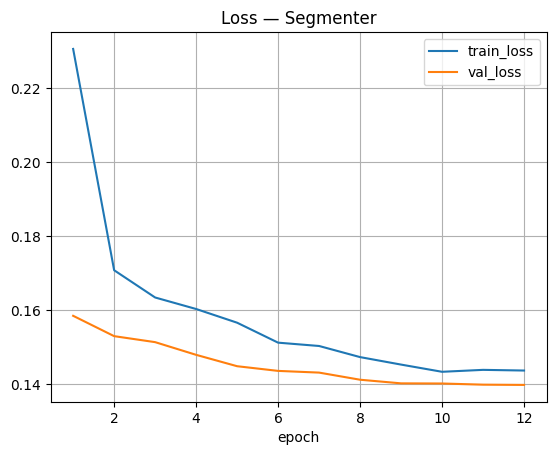

In [9]:
seg = smp.UnetPlusPlus(encoder_name=CFG.ENCODER, encoder_weights='imagenet',
                       in_channels=1, classes=1, activation=None).to(DEVICE)
criterion = BCETverskyLoss()
opt = torch.optim.AdamW(seg.parameters(), lr=CFG.SEG_LR, weight_decay=5e-5)
sched = CosineAnnealingLR(opt, T_max=CFG.SEG_EPOCHS)
scaler = torch.amp.GradScaler('cuda')

best_dice, no_improve, seg_history = 0.0, 0, []
for ep in range(1, CFG.SEG_EPOCHS + 1):
    seg.train(); tl = 0.0; t0 = time.time()
    for x, y in train_loader:
        x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)
        opt.zero_grad(set_to_none=True)
        with torch.amp.autocast('cuda'):
            loss = criterion(seg(x), y)
        scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
        tl += loss.item() * x.size(0)
    tl /= len(train_crops)

    seg.eval(); vl = vd = 0.0
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            with torch.amp.autocast('cuda'):
                logits = seg(x)
            vl += criterion(logits.float(), y).item() * x.size(0)
            vd += dice_score(logits.float(), y).item() * x.size(0)
    vl /= len(val_crops); vd /= len(val_crops)
    sched.step()
    seg_history.append(dict(epoch=ep, train_loss=tl, val_loss=vl, val_dice=vd))

    tag = ''
    if vd > best_dice:
        best_dice, no_improve = vd, 0
        torch.save(seg.state_dict(), '/kaggle/working/best_seg.pth'); tag = '  <- best'
    else:
        no_improve += 1
    print(f'Ep {ep:02d}/{CFG.SEG_EPOCHS} | train {tl:.4f} | val {vl:.4f} | '
          f'Dice {vd:.4f} | {time.time()-t0:.0f}s{tag}')
    if no_improve >= CFG.SEG_PATIENCE:
        print(f'Early stopping at epoch {ep}'); break

print(f'\nBest crop Dice (validation): {best_dice:.4f}')
seg_hist = pd.DataFrame(seg_history)
seg_hist.plot(x='epoch', y=['train_loss', 'val_loss'], grid=True, title='Loss — Segmenter'); plt.show()


In [10]:
seg.load_state_dict(torch.load('/kaggle/working/best_seg.pth', map_location=DEVICE))
seg.eval()
det = YOLO(DET_WEIGHTS)


def predict_crops_tta(model, batch_tensor, use_tta=CFG.USE_TTA):
    # Segmenter Test-Time Augmentation (Original + Horizontal Flip + Vertical Flip)
    with torch.amp.autocast('cuda'):
        p_orig = torch.sigmoid(model(batch_tensor))
        if use_tta:
            p_h = torch.sigmoid(model(torch.flip(batch_tensor, dims=[3])))
            p_h = torch.flip(p_h, dims=[3])
            p_v = torch.sigmoid(model(torch.flip(batch_tensor, dims=[2])))
            p_v = torch.flip(p_v, dims=[2])
            probs = (p_orig + p_h + p_v) / 3.0
        else:
            probs = p_orig
    return probs.float().cpu().numpy()[:, 0]


@torch.no_grad()
def cache_predictions(image_path):
    img_raw = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
    h, w = img_raw.shape
    img = preprocess_image(img_raw)
    
    # Detector inference at native trained resolution (1280)
    bgr = cv2.cvtColor(img_raw, cv2.COLOR_GRAY2BGR)
    r = det.predict(bgr, imgsz=CFG.INFER_IMGSZ, conf=CFG.CONF_MIN,
                    max_det=CFG.MAX_DET, verbose=False)[0]
    boxes = r.boxes.xyxy.cpu().numpy(); confs = r.boxes.conf.cpu().numpy()
    if len(boxes) == 0:
        return [], (h, w)

    crops, metas = [], []
    for (x1, y1, x2, y2), c in zip(boxes, confs):
        bw, bh = x2 - x1, y2 - y1
        pw, ph = bw * CFG.PAD_RATIO, bh * CFG.PAD_RATIO
        cx1, cy1 = max(0, int(x1 - pw)), max(0, int(y1 - ph))
        cx2, cy2 = min(w, int(x2 + pw)), min(h, int(y2 + ph))
        if cx2 <= cx1 + 1 or cy2 <= cy1 + 1:
            continue
        crop = cv2.resize(img[cy1:cy2, cx1:cx2], (CFG.CROP_SIZE, CFG.CROP_SIZE))
        crops.append((crop.astype('float32') / 255.0 - 0.5) / 0.5)
        metas.append((float(c), (cx1, cy1, cx2, cy2)))

    out = []
    for i in range(0, len(crops), 16):
        batch = torch.from_numpy(np.stack(crops[i:i+16]))[:, None].float().to(DEVICE)
        probs = predict_crops_tta(seg, batch, use_tta=CFG.USE_TTA)
        for p, (c, box) in zip(probs, metas[i:i+16]):
            cx1, cy1, cx2, cy2 = box
            out.append(dict(conf=c, box=box,
                            probs=cv2.resize(p, (cx2 - cx1, cy2 - cy1)).astype('float16')))
    return out, (h, w)


def paint_panoptic(cached, shape, conf_t, mask_t, min_area=CFG.MIN_AREA):
    # In descending confidence order: each pixel goes to the first filament claiming it -> disjoint instances
    h, w = shape
    items = sorted([it for it in cached if it['conf'] >= conf_t], key=lambda d: -d['conf'])
    occupied = np.zeros((h, w), dtype=bool)
    masks = []
    
    # Morphological closing kernel to bridge thin barb gaps
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (CFG.CLOSE_KERNEL, CFG.CLOSE_KERNEL)) if CFG.CLOSE_KERNEL > 1 else None
    
    for it in items:
        cx1, cy1, cx2, cy2 = it['box']
        raw_mask = (it['probs'].astype('float32') > mask_t).astype(np.uint8)
        
        if kernel is not None and raw_mask.sum() > 0:
            raw_mask = cv2.morphologyEx(raw_mask, cv2.MORPH_CLOSE, kernel)
        
        m = np.zeros((h, w), dtype=bool)
        m[cy1:cy2, cx1:cx2] = raw_mask.astype(bool)
        m &= ~occupied
        
        if m.sum() < min_area:
            continue
            
        occupied |= m
        masks.append(m)
    return masks


In [11]:
def iou_matrix(gt_masks, pred_masks):
    if not gt_masks or not pred_masks:
        return np.zeros((len(gt_masks), len(pred_masks)), dtype=np.float32)
    G = torch.from_numpy(np.stack([m.ravel() for m in gt_masks])).to(DEVICE).half()
    P = torch.from_numpy(np.stack([m.ravel() for m in pred_masks])).to(DEVICE).half()
    inter = (G @ P.t()).float()
    union = G.sum(1).float()[:, None] + P.sum(1).float()[None, :] - inter
    out = torch.where(union > 0, inter / union, torch.zeros_like(inter)).cpu().numpy()
    del G, P
    return out


class PQAccumulator:
    def __init__(self, thr=0.5):
        self.thr, self.tp_ious, self.fp, self.fn = thr, [], 0, 0

    def add(self, iou):
        n_gt, n_pred = iou.shape
        if n_gt == 0:
            self.fp += n_pred; return
        if n_pred == 0:
            self.fn += n_gt; return
        hit = iou > self.thr
        self.tp_ious.extend(iou[hit].tolist())
        self.fp += int((hit.sum(0) == 0).sum())
        self.fn += int((hit.sum(1) == 0).sum())

    def result(self):
        tp = len(self.tp_ious)
        den = tp + 0.5 * self.fp + 0.5 * self.fn
        sq = sum(self.tp_ious) / tp if tp else 0.0
        dq = tp / den if den else 0.0
        return dict(PQ=dq * sq, DQ=dq, SQ=sq, TP=tp, FP=self.fp, FN=self.fn)


def gt_masks_by_annotator(fname):
    # {image_id: [masks]} — one set per annotator for this photo
    return {iid: [coco.annToMask(a).astype(bool)
                  for a in coco.loadAnns(coco.getAnnIds(imgIds=[iid]))]
            for iid in photo_to_ids[fname]}


In [12]:
# --- Sweep conf x mask_threshold over a validation subset ---
rng = np.random.default_rng(CFG.SEED)
sweep_photos = list(rng.choice(val_photos, size=min(CFG.SWEEP_PHOTOS, len(val_photos)), replace=False))
grid = [(c, m) for c in CFG.CONF_GRID for m in CFG.MASK_GRID]
accs = {k: PQAccumulator() for k in grid}

t0 = time.time()
for n, fname in enumerate(sweep_photos, 1):
    cached, shape = cache_predictions(TRAIN_IMG_DIR / fname)
    gts = gt_masks_by_annotator(fname)
    for combo in grid:
        preds = paint_panoptic(cached, shape, *combo)
        for masks in gts.values():
            accs[combo].add(iou_matrix(masks, preds))
    del cached; gc.collect()
    if n % 10 == 0:
        print(f'  {n}/{len(sweep_photos)} photos · {time.time()-t0:.0f}s')

sweep = pd.DataFrame([{'conf': c, 'mask_thr': m, **accs[(c, m)].result()} for c, m in grid]
                     ).sort_values('PQ', ascending=False).reset_index(drop=True)
BEST_CONF, BEST_MASK = float(sweep.iloc[0]['conf']), float(sweep.iloc[0]['mask_thr'])
print(f'\nBest combination: conf={BEST_CONF} · mask_thr={BEST_MASK} · PQ={sweep.iloc[0].PQ:.4f}')
display(sweep.round(4))


  10/40 photos · 154s
  20/40 photos · 233s
  30/40 photos · 280s
  40/40 photos · 370s

Best combination: conf=0.35 · mask_thr=0.6 · PQ=0.4130


,conf,mask_thr,PQ,DQ,SQ,TP,FP,FN
0,0.35,0.6,0.4130,0.6105,0.6765,268,153,189
1,0.35,0.5,0.4110,0.6073,0.6768,266,153,191
2,0.35,0.4,0.4054,0.5991,0.6766,263,158,194
3,0.30,0.6,0.3895,0.5766,0.6755,271,212,186
4,0.30,0.5,0.3887,0.5757,0.6753,270,211,187
5,0.25,0.6,0.3837,0.5682,0.6752,279,246,178
6,0.30,0.4,0.3836,0.5681,0.6752,267,216,190
7,0.25,0.5,0.3830,0.5673,0.6750,278,245,179
8,0.25,0.4,0.3780,0.5601,0.6749,275,250,182
9,0.20,0.6,0.3692,0.5479,0.6739,289,309,168


In [13]:
# --- Final PQ over ENTIRE validation set with the best combination ---
acc = PQAccumulator()
t0 = time.time()
for n, fname in enumerate(val_photos, 1):
    cached, shape = cache_predictions(TRAIN_IMG_DIR / fname)
    preds = paint_panoptic(cached, shape, BEST_CONF, BEST_MASK)
    for masks in gt_masks_by_annotator(fname).values():
        acc.add(iou_matrix(masks, preds))
    del cached; gc.collect()
    if n % 20 == 0:
        print(f'  {n}/{len(val_photos)} · {time.time()-t0:.0f}s')

VAL_PQ = acc.result()
print('\n' + '=' * 60)
print(f"PQ {VAL_PQ['PQ']:.4f}  |  DQ {VAL_PQ['DQ']:.4f}  |  SQ {VAL_PQ['SQ']:.4f}")
print(f"TP {VAL_PQ['TP']}  |  FP {VAL_PQ['FP']}  |  FN {VAL_PQ['FN']}")
print('=' * 60)
print('Reference: agreement between human annotators ≈ 0.36')


  20/107 · 25s
  40/107 · 56s
  60/107 · 78s
  80/107 · 103s
  100/107 · 133s

PQ 0.4145  |  DQ 0.6093  |  SQ 0.6802
TP 815  |  FP 466  |  FN 579
Reference: agreement between human annotators ≈ 0.36


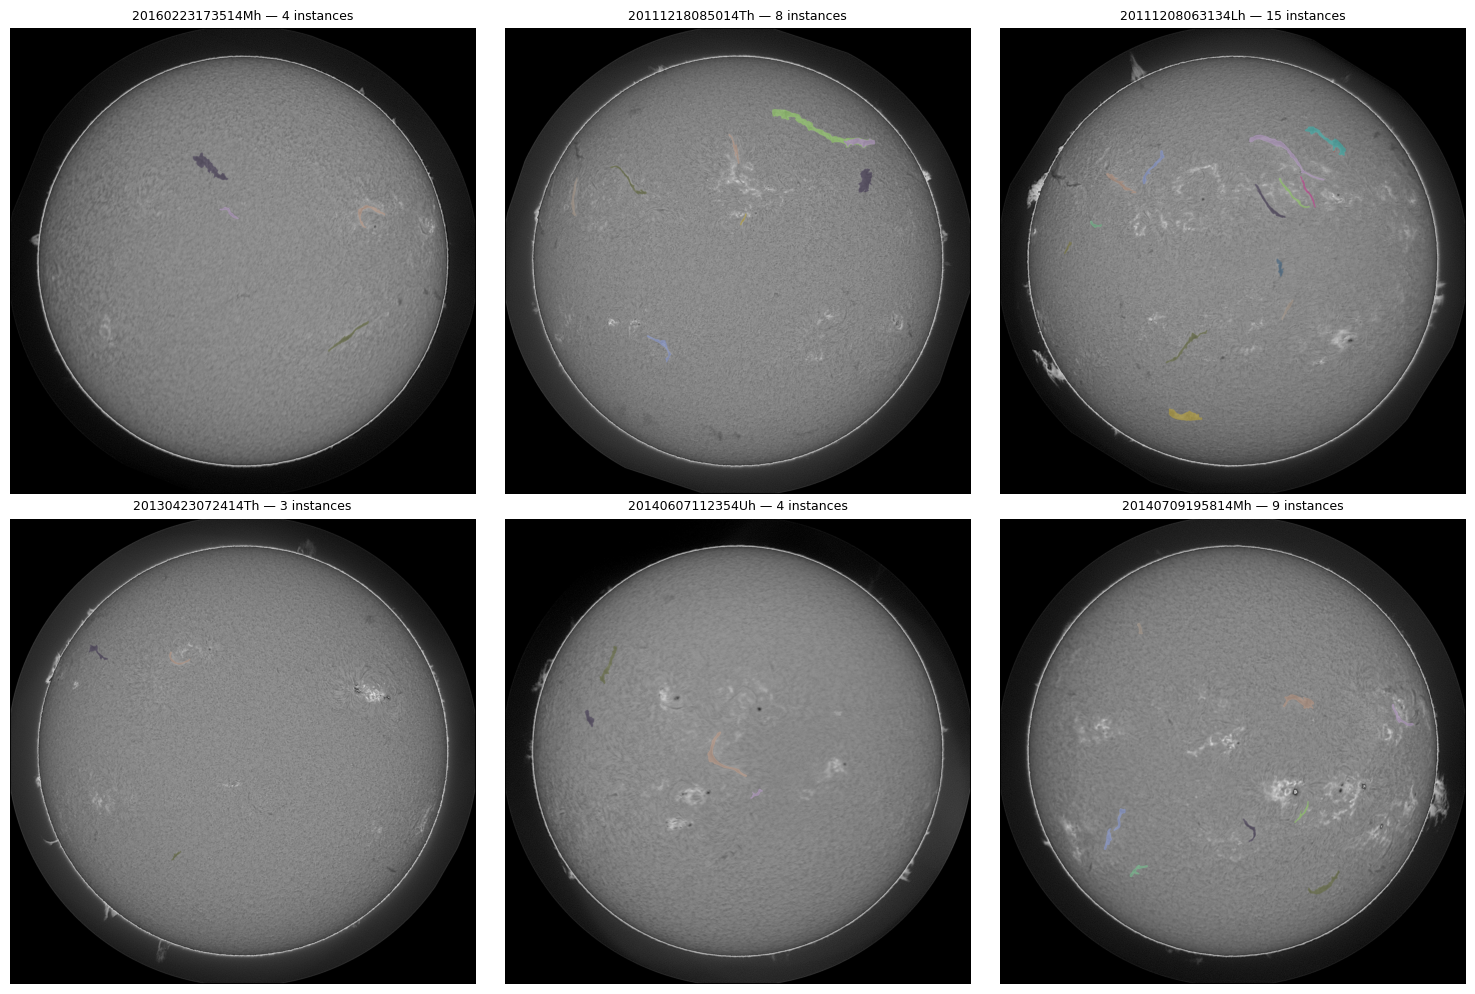

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for ax, fname in zip(axes.ravel(), val_photos[:6]):
    img = cv2.imread(str(TRAIN_IMG_DIR / fname), cv2.IMREAD_GRAYSCALE)
    cached, shape = cache_predictions(TRAIN_IMG_DIR / fname)
    preds = paint_panoptic(cached, shape, BEST_CONF, BEST_MASK)
    rgb = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    r = np.random.default_rng(0)
    for m in preds:
        rgb[m] = (0.45 * rgb[m] + 0.55 * r.integers(60, 240, 3)).astype(np.uint8)
    ax.imshow(rgb); ax.set_title(f'{Path(fname).stem} — {len(preds)} instances', fontsize=9)
    ax.axis('off')
plt.tight_layout(); plt.show()


In [15]:
rows = []
t0 = time.time()
for n, path in enumerate(test_paths, 1):
    stem = path.stem
    cached, shape = cache_predictions(path)
    for k, m in enumerate(paint_panoptic(cached, shape, BEST_CONF, BEST_MASK), start=1):
        rows.append({'filament_id': f'{stem}_{k}', 'segmentation_rle': mask_to_rle(m)})
    del cached; gc.collect()
    if n % 30 == 0:
        print(f'  {n}/{len(test_paths)} · {time.time()-t0:.0f}s')

submission = pd.DataFrame(rows)
submission.to_csv('/kaggle/working/submission.csv', index=False)
print(f'\n{len(submission)} rows · {submission.filament_id.str.rsplit("_", n=1).str[0].nunique()} images with predictions out of {len(test_paths)}')
display(submission.head())


  30/180 · 33s
  60/180 · 66s
  90/180 · 104s
  120/180 · 135s
  150/180 · 155s
  180/180 · 177s

1152 rows · 177 images with predictions out of 180


,filament_id,segmentation_rle
0,20110120105534Ch_1,UjTQ23lo11O1O1O1O1N1000O1O01O01000O101OOL5O1L5...
1,20110120105534Ch_2,^`Vj28ho12N1O1O1O2O000001N1O1O10O01O10O001O10O...
2,20110130110334Ch_1,d_nd27go15L2O2`PNA[o1d0N010O0nPN^Ogn1b0WQNAhn1...
3,20110214175414Mh_1,gYag2a0]o13O0O1O1O1O1O00OOO21000000O1O10000000...
4,20110214175414Mh_2,U]h[29eo14J6J5N1QOXOfRNi0Wm1ZOgRNh0Wm1ZOhRNf0W...


In [16]:
# --- Disjointness verification BEFORE using submission quota ---
def rle_to_mask(rle, shape=(H, W)):
    return mask_utils.decode({'counts': rle.encode('utf-8'), 'size': list(shape)})

problems = 0
for image_id, grp in submission.groupby(submission.filament_id.str.rsplit('_', n=1).str[0]):
    combined = np.zeros((H, W), dtype=np.uint8)
    for _, r in grp.iterrows():
        m = rle_to_mask(r.segmentation_rle)
        if (combined & m).sum() > 0:
            print(f'OVERLAP in {r.filament_id}'); problems += 1
        combined |= m

assert submission.filament_id.is_unique, 'duplicate filament_id'
assert not submission.segmentation_rle.str.contains('"').any(), 'quotes in RLE'
print('No overlaps. Ready to submit.' if problems == 0 else f'{problems} overlaps — DO NOT submit.')


No overlaps. Ready to submit.


In [17]:
print('=' * 64)
print(f'RUN: {RUN_NAME}')
print('=' * 64)
print(f'Detector      : {CFG.DETECTOR} @ {CFG.DET_IMGSZ}, batch {CFG.DET_BATCH}, {CFG.DET_EPOCHS} epochs')
print('  ' + ' | '.join(f'{k} {v:.4f}' for k, v in DET_METRICS.items()))
print(f'Segmenter     : UNet++/{CFG.ENCODER} @ {CFG.CROP_SIZE}, jitter {CFG.BOX_JITTER}')
print(f'  best crop Dice: {best_dice:.4f} (epoch {int(seg_hist.val_dice.idxmax())+1} of {len(seg_hist)})')
print(f'Inference     : imgsz {CFG.INFER_IMGSZ} (≠ {CFG.DET_IMGSZ}, deliberate defect), '
      f'conf {BEST_CONF}, mask_thr {BEST_MASK}, min_area {CFG.MIN_AREA}')
print('-' * 64)
print(f"VALIDATION PQ : {VAL_PQ['PQ']:.4f}   (DQ {VAL_PQ['DQ']:.4f} · SQ {VAL_PQ['SQ']:.4f})")
print(f"                TP {VAL_PQ['TP']} · FP {VAL_PQ['FP']} · FN {VAL_PQ['FN']}")
print(f'Submission    : {len(submission)} rows')
print(f'Public score  : ____  <- record after submission')
print('=' * 64)

seg_hist.to_csv('/kaggle/working/seg_history.csv', index=False)
sweep.to_csv('/kaggle/working/threshold_sweep.csv', index=False)
print('Saved seg_history.csv and threshold_sweep.csv to /kaggle/working/')


RUN: V1_baseline
Detector      : yolo11m.pt @ 1280, batch 8, 40 epochs
  mAP50 0.6369 | mAP50_95 0.3760 | precision 0.6154 | recall 0.6346
Segmenter     : UNet++/efficientnet-b4 @ 512, jitter 0.0
  best crop Dice: 0.8433 (epoch 10 of 12)
Inference     : imgsz 1024 (≠ 1280, deliberate defect), conf 0.35, mask_thr 0.6, min_area 0
----------------------------------------------------------------
VALIDATION PQ : 0.4145   (DQ 0.6093 · SQ 0.6802)
                TP 815 · FP 466 · FN 579
Submission    : 1152 rows
Public score  : ____  <- record after submission
Saved seg_history.csv and threshold_sweep.csv to /kaggle/working/
